# Individual contribution to annotated clusters at D16

## Human, Chimp, Orangutan and Macaque



## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt
import scrublet 


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()


The `sinfo` package has changed name and is now called `session_info` to become more discoverable and self-explanatory. The `sinfo` PyPI package will be kept around to avoid breaking old installs and you can downgrade to 0.3.2 if you want to use it without seeing this message. For the latest features and bug fixes, please install `session_info` instead. The usage and defaults also changed slightly, so please review the latest README at https://gitlab.com/joelostblom/session_info.
-----
anndata     0.8.0
scanpy      1.8.2
sinfo       0.3.4
-----
PIL                         9.0.1
annoy                       NA
appnope                     0.1.2
asttokens                   NA
backcall                    0.2.0
bbknn                       NA
beta_ufunc                  NA
binom_ufunc                 NA
cffi                        1.15.0
colorama                    0.4.4
cycler                      0.10.0
cython_runtime              NA
dateutil                    2.8.2
debugpy                

In [3]:
pwd

'/Users/saranolbrant/Dropbox/Postdoc Pollen lab/Comparative DA study/10x Multiome sequencing/10x GEX data/20220406_SN_DA013_D16v2_D40_D100_D80_GEX'

In [4]:
#set a path to your working directory
directory='Set/your/path'


adata = sc.read_h5ad(directory+'/Written_files/D16_GEX_processed-clustered.h5ad')




In [5]:
adata.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,species,pool_type,experiment,lane,n_genes,percent_mito,percent_ribo,n_counts,leiden
AAACAGCCATAATTGC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,5216,0.058167,0.034581,16520.0,8
AAACATGCACCTGCTC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,5329,0.136612,0.057923,15791.0,12
AAACCAACAGGGAGCT-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,1822,0.110940,0.029276,3461.0,6
AAACCGGCAGGACCTT-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,6380,0.145024,0.017703,24611.0,8
AAACCGGCAGGCCAAA-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,4872,0.131819,0.035035,13866.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTAACGAGG-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C3624,S,15.327100,chimp,Interspecies,first_experiment,Lane3,1894,0.061906,0.042254,2864.0,3
TTTGTTGGTCTATCGT-1-D16_M_Chimp,D16_M_Chimp,singlet,C.4,C.4,C3651,S,47.776978,chimp,Interspecies,first_experiment,Lane3,2705,0.109701,0.048232,4908.0,8
TTTGTTGGTTAGTACG-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C40670,S,3.590251,chimp,Interspecies,first_experiment,Lane3,2258,0.034186,0.017220,3813.0,11
TTTGTTGGTTCCTGAT-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C4933,S,3.656368,chimp,Interspecies,first_experiment,Lane3,1746,0.130795,0.027152,2625.0,2


In [6]:
adata

AnnData object with n_obs × n_vars = 73077 × 40500
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden'
    var: 'gene_ids-D16_CH2_Chimp', 'feature_types-D16_CH2_Chimp', 'genome-D16_CH2_Chimp', 'gene_ids-D16_CH2_Human', 'feature_types-D16_CH2_Human', 'genome-D16_CH2_Human', 'gene_ids-D16_CH_Chimp', 'feature_types-D16_CH_Chimp', 'genome-D16_CH_Chimp', 'gene_ids-D16_CH_Human', 'feature_types-D16_CH_Human', 'genome-D16_CH_Human', 'gene_ids-D16_M0_5_Chimp', 'feature_types-D16_M0_5_Chimp', 'genome-D16_M0_5_Chimp', 'gene_ids-D16_M0_5_Human', 'feature_types-D16_M0_5_Human', 'genome-D16_M0_5_Human', 'gene_ids-D16_M0_5_Orangutan', 'feature_types-D16_M0_5_Orangutan', 'genome-D16_M0_5_Orangutan', 'gene_ids-D16_M0_5_Rhesus', 'feature_types-D16_M0_5_Rhesus', 'genome-D16_M0_5_Rhesus', 'gene_ids-D16_M2_Chimp', 'feature_types-D16_M2

In [7]:
individual_pooltype = pd.Categorical(adata.obs['individual'].astype(str) + ('_') + adata.obs['pool_type'].astype(str))

adata.obs['individual_pooltype'] = individual_pooltype

In [8]:
adata.obs['individual_pooltype'].value_counts()

C8861_Interspecies          5095
C3651_Interspecies          4273
C4933_Interspecies          4122
C8861_Intraspecies          3561
H20961_Intraspecies         3517
H20961_Interspecies         3314
C4933_Intraspecies          3070
C3651_Intraspecies          2762
H29089_Intraspecies         2621
H29089_Interspecies         2323
C40300_Interspecies         2290
C40670_Interspecies         2204
C40210_Interspecies         2073
H21792_Interspecies         1946
C3624_Interspecies          1930
H9_Intraspecies             1812
H28126_Interspecies         1803
H28126_Intraspecies         1636
C40300_Intraspecies         1621
H23555_Intraspecies         1618
H9_Interspecies             1616
H21194_Interspecies         1587
H21194_Intraspecies         1586
C40670_Intraspecies         1562
H21792_Intraspecies         1451
ZG15-M11-10_Intraspecies    1449
H23555_Interspecies         1397
C3624_Intraspecies          1367
ES_Lyon_Intraspecies        1188
H28834_Interspecies         1177
C40210_Int

In [81]:
#Change the values of this dictionary to assign the name you want to each of the leiden clusters
labeldict={'0':'9. Caudal vMB progenitors',
           '1':'6. vMB progenitors',
           '2':'6. vMB progenitors',
           '3':'1. vFB progenitors',
           '4':'7. vMB progenitors (cycling, G1/S phase)',
           '5':'4. Caudal vFB/rostral vMB progenitors',
           '6':'1. vFB progenitors',
           '7':'10. vMB/BP progenitors',
           '8':'3. vFB progenitors (cycling, M/G2 phase)',
           '9':'12. Rostral vHB progenitors',
           '10':'15. Progenitors (subtype unknown)',
           '11':'8. vMB progenitors (cycling, M/G2 phase)',
           '12':'6. vMB progenitors',
           '13':'13. vHB progenitors (cycling)',
           '14':'5. vFB/vMB progenitors (cycling)',
           '15':'8. vMB progenitors (cycling, M/G2 phase)',
           '16':'2. vFB progenitors (cycling, G1/S phase)',
           '17':'11. vMB/vHB progenitors',
           '18':'17. Glutamatergic neurons',
           '19':'14. Progenitors (high ECM/Actin-regulation)',
           '20':'16. Immature neurons and motor neurons',
           '21':'5. vFB/vMB progenitors (cycling)',
           '22':'6. vMB progenitors',

           }

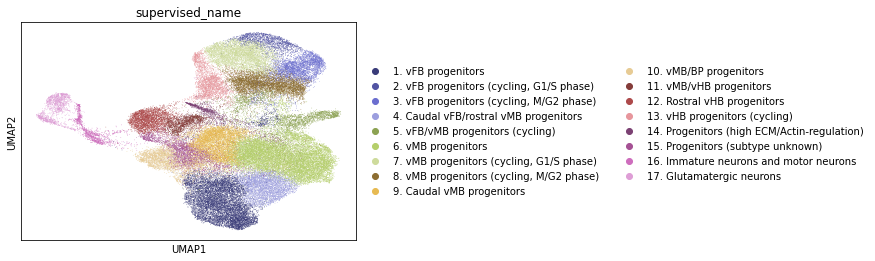

In [90]:
#Assign a supervised name for each leiden cluster
#Will error out if you missed a cluster

adata.obs['supervised_name']=[labeldict[x] for x in adata.obs['leiden']]
sc.pl.umap(adata,color=['supervised_name'], palette="tab20b")

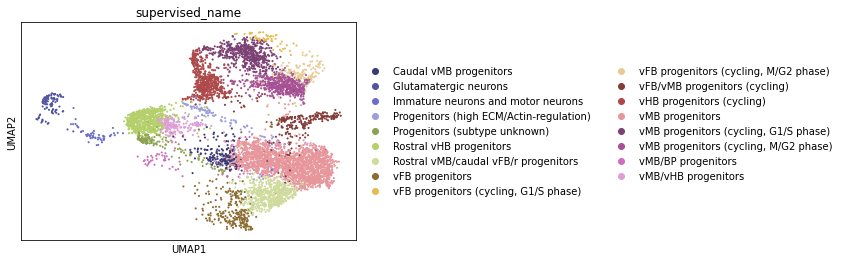

In [52]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H20961_Interspecies|H20961_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_H20961')

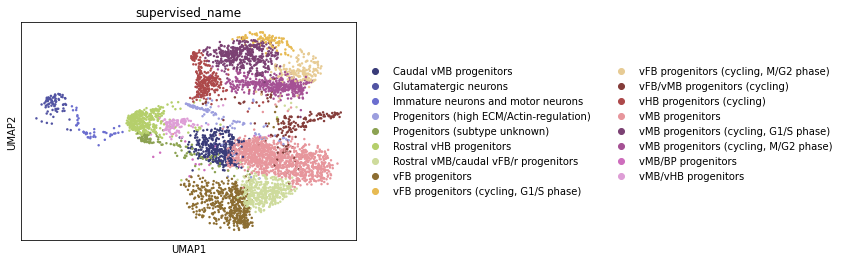

In [54]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H29089_Interspecies|H29089_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_H29089.pdf')

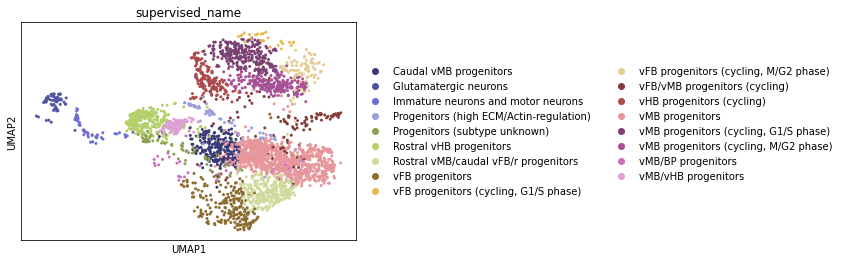

In [55]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H21792_Interspecies|H21792_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_H21792.pdf')

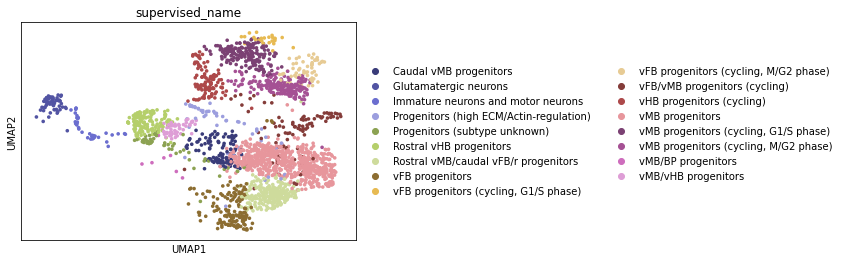

In [56]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H28834_Intraspecies|H28834_Interspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_H8834.pdf')

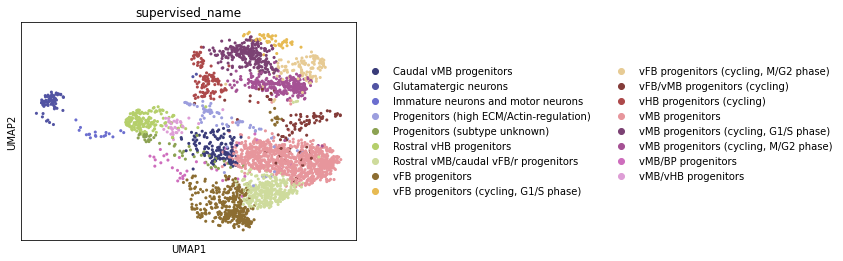

In [57]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H21194_Interspecies|H21194_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_21194.pdf')

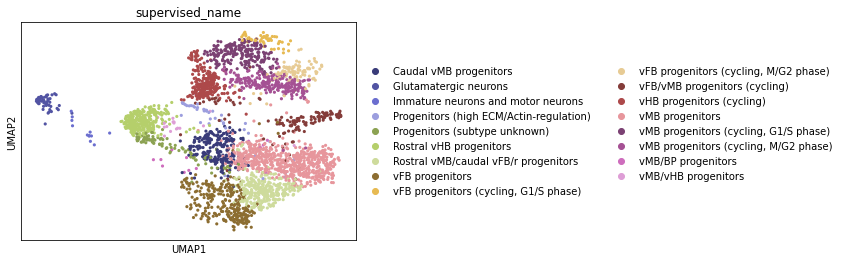

In [59]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H23555_Interspecies|H23555_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_23555.pdf')

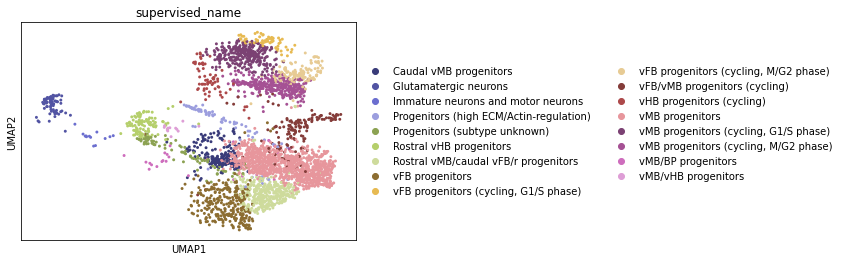

In [60]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H28126_Interspecies|H28126_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_H28126.pdf')

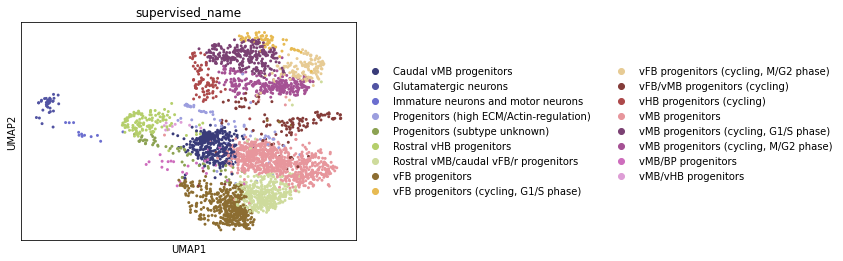

In [61]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H9_Interspecies|H9_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_H9.pdf')

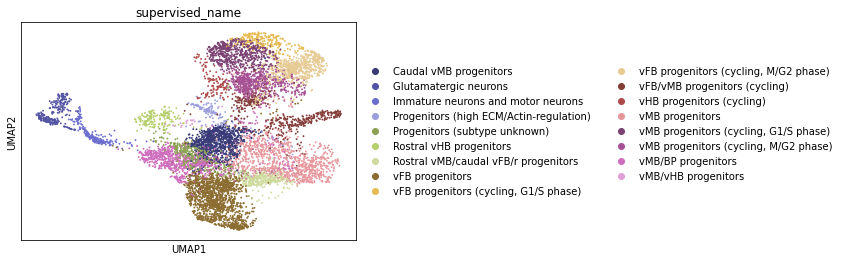

In [62]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C8861_Interspecies|C8861_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_C8861.pdf')

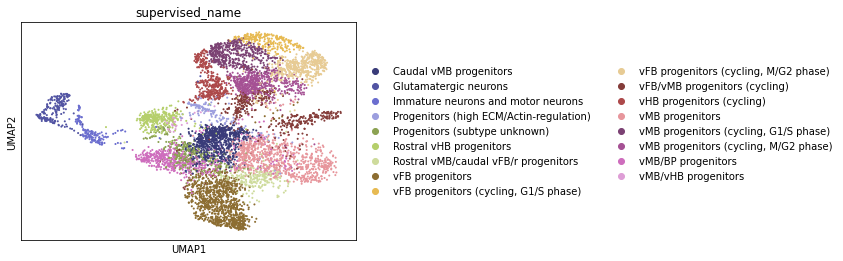

In [63]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C4933_Interspecies|C4933_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_C4933.pdf')

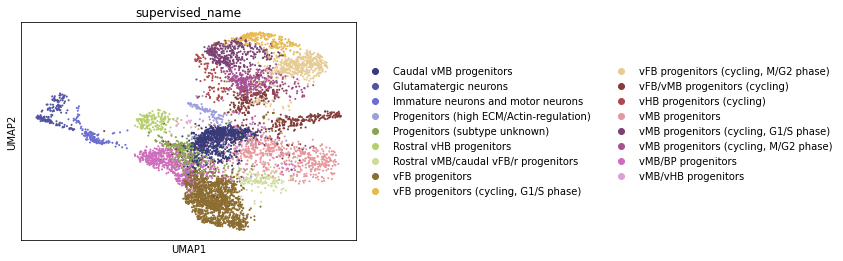

In [64]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C3651_Interspecies|C3651_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_C3651.pdf')

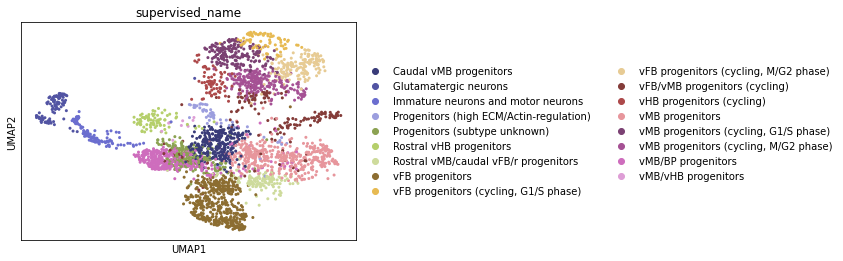

In [65]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C3624_Interspecies|C3624_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_C3624.pdf')

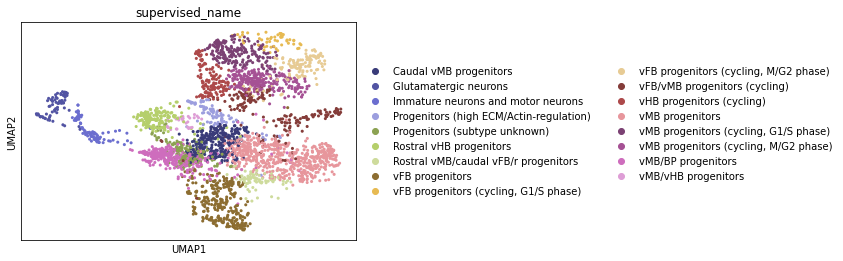

In [66]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C40210_Interspecies|C40210_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_C40210.pdf')

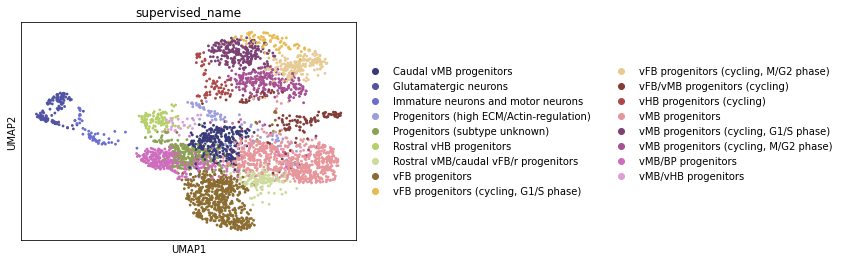

In [67]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C40670_Interspecies|C40670_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_D16_C40670.pdf')

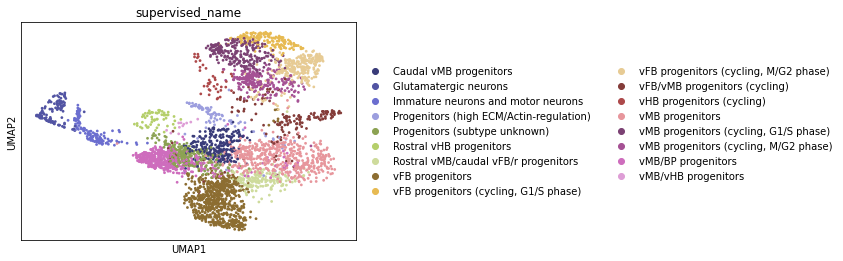

In [69]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C40300_Interspecies|C40300_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name',save='_D16_C40300.pdf')

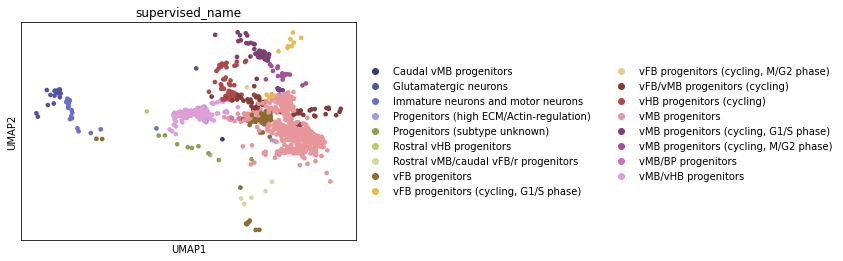

In [70]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('ES_Lyon_Interspecies|ES_Lyon_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name',save='_D16_LYON-ES1.pdf')

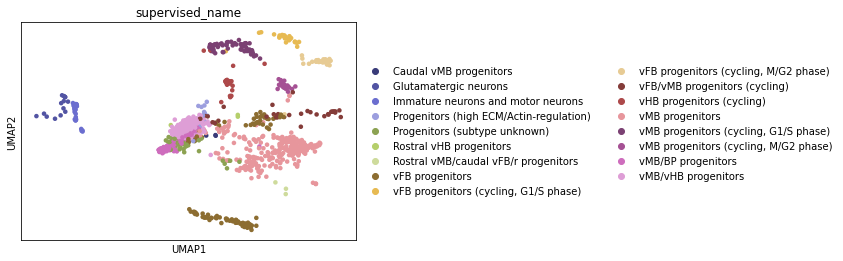

In [71]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('ZG15-M11-10_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name',save='_D16_ZG15.pdf')

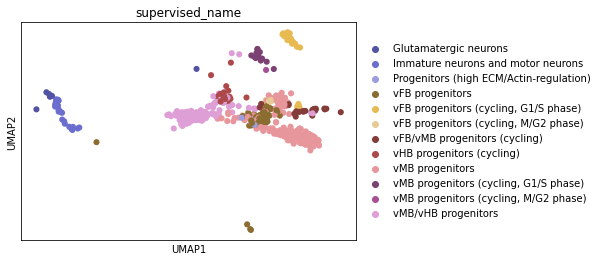

In [72]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('ZH26-HS16_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name',save='_D16_ZH26.pdf')

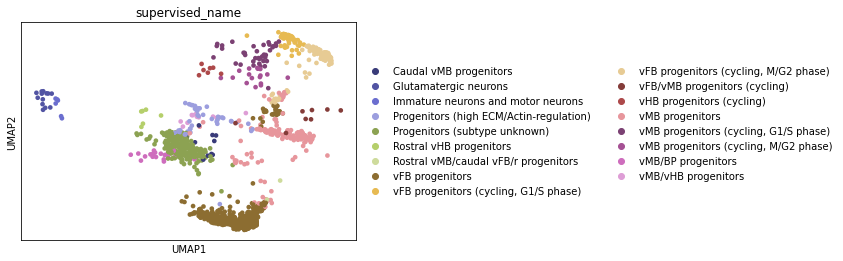

In [84]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('O11045-4593_Intraspecies|O11045-4593_Interspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name',save='_D16_O11045.pdf')

In [119]:
# Set color scheme
custom_colors = {
    '1. vFB progenitors': 'darkgoldenrod',
    '2. vFB progenitors (cycling, G1/S phase)': 'gold',
    '3. vFB progenitors (cycling, M/G2 phase)': 'wheat',
    '4. Caudal vFB/rostral vMB progenitors': 'lightgreen',
    '5. vFB/vMB progenitors (cycling)': 'saddlebrown',
    '6. vMB progenitors': 'salmon',
    '7. vMB progenitors (cycling, G1/S phase)': 'purple',
    '8. vMB progenitors (cycling, M/G2 phase)': 'rebeccapurple',
    '9. Caudal vMB progenitors': 'midnightblue',
    '10. vMB/BP progenitors': 'violet',
    '11. vMB/vHB progenitors': 'plum',
    '12. Rostral vHB progenitors': 'yellowgreen',
    '13. vHB progenitors (cycling)': 'sienna',
    '14. Progenitors (high ECM/Actin-regulation)': 'slateblue',
    '15. Progenitors (subtype unknown)': 'olivedrab',
    '16. Immature neurons and motor neurons': 'mediumslateblue',
    '17. Glutamatergic neurons': 'darkslateblue',
}

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

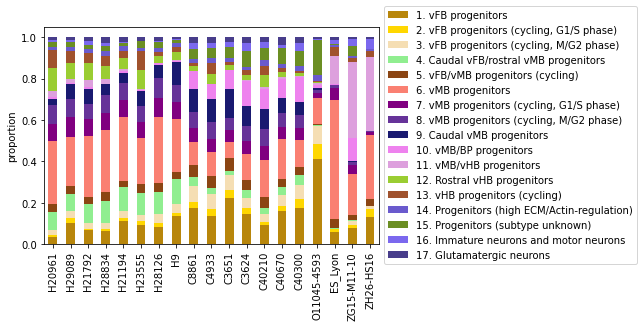

<Figure size 432x288 with 0 Axes>

In [120]:
f = plt.figure()
df_plot = adata.obs.groupby(['supervised_name', 'individual']).size().reset_index().pivot(columns='supervised_name', index='individual', values=0).apply(lambda g: g / g.sum(),1)

#Extract cell_types names from the columns
supervised_names = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(supervised_name, None) for supervised_name in supervised_names]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

#Define the desired order for 'supervised_name'
desired_order = ['H20961','H29089',
                'H21792','H28834',
                'H21194','H23555',
                'H28126','H9',
                'C8861','C4933',
                'C3651','C3624',
                'C40210','C40670',
                'C40300','O11045-4593','ES_Lyon',
                 'ZG15-M11-10','ZH26-HS16',
                  ]
                 
# Set the order as a Categorical type
df_plot.index = pd.Categorical(df_plot.index, categories=desired_order, ordered=True)

# Sort by the new categorical order
df_plot = df_plot.sort_index()


# Plot
f = plt.figure()
ax = df_plot.plot(kind='bar', legend=False, stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')
plt.show()
plt.savefig('boxplot_D16-individual.pdf', format='pdf')

<Figure size 432x288 with 0 Axes>

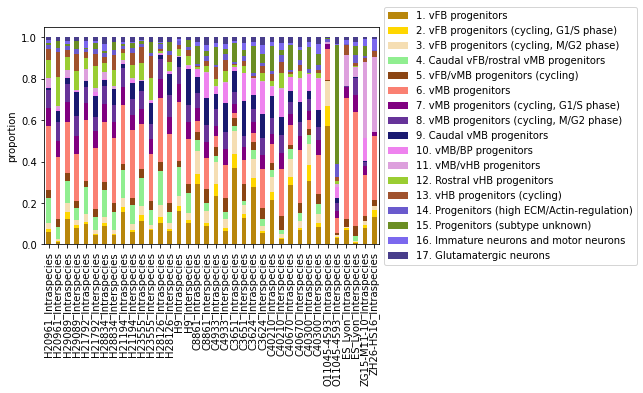

<Figure size 432x288 with 0 Axes>

In [121]:
adata_inter_intra = adata[~adata.obs['individual_pooltype'].isin(['nan_Interspecies','nan_Intraspecies' ])]
df_plot = adata_inter_intra.obs.groupby(['supervised_name', 'individual_pooltype']).size().reset_index().pivot(columns='supervised_name', index='individual_pooltype', values=0).apply(lambda g: g / g.sum(),1)

#Define the desired order for 'supervised_name'
desired_order = ['H20961_Intraspecies','H20961_Interspecies','H29089_Intraspecies','H29089_Interspecies',
                'H21792_Intraspecies','H21792_Interspecies','H28834_Intraspecies','H28834_Interspecies',
                'H21194_Intraspecies','H21194_Interspecies','H23555_Intraspecies','H23555_Interspecies',
                'H28126_Intraspecies','H28126_Interspecies','H9_Intraspecies','H9_Interspecies',
                'C8861_Intraspecies','C8861_Interspecies','C4933_Intraspecies','C4933_Interspecies',
                'C3651_Intraspecies','C3651_Interspecies','C3624_Intraspecies','C3624_Interspecies',
                'C40210_Intraspecies','C40210_Interspecies','C40670_Intraspecies','C40670_Interspecies',
                'C40300_Intraspecies','C40300_Interspecies','O11045-4593_Intraspecies', 'O11045-4593_Interspecies',
                 'ES_Lyon_Intraspecies','ES_Lyon_Interspecies','ZG15-M11-10_Intraspecies','ZH26-HS16_Intraspecies']
                 
# Set the order as a Categorical type
df_plot.index = pd.Categorical(df_plot.index, categories=desired_order, ordered=True)

# Sort by the new categorical order
df_plot = df_plot.sort_index()


# Plot
f = plt.figure()
ax = df_plot.plot(kind='bar', legend=False, stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')
plt.show()
plt.savefig('boxplot_D16-individual-pooltype.pdf', format='pdf')